In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1. Dados
df    = yf.download("PETR4.SA", start="2015-01-01", end="2026-01-01", auto_adjust=True)
serie = df["Close"].squeeze()
serie = serie / serie.iloc[0]
display(serie.head())

[*********************100%***********************]  1 of 1 completed


Date
2015-01-02    1.000000
2015-01-05    0.914530
2015-01-06    0.884616
2015-01-07    0.926282
2015-01-08    0.986111
Name: PETR4.SA, dtype: float64

In [4]:
# 2. High Water Mark
hwm = serie.cummax()
display(hwm.head())

Date
2015-01-02    1.0
2015-01-05    1.0
2015-01-06    1.0
2015-01-07    1.0
2015-01-08    1.0
Name: PETR4.SA, dtype: float64

In [6]:
# 3. Drawdown
drawdown = (serie - hwm) / hwm
display(drawdown.describe())

count    2737.000000
mean       -0.157897
std         0.146007
min        -0.708940
25%        -0.251649
50%        -0.112240
75%        -0.048515
max         0.000000
Name: PETR4.SA, dtype: float64

In [7]:
# 4. Max Drawdown
max_dd    = drawdown.min()
trough_dt = drawdown.idxmin()
peak_dt   = serie[:trough_dt].idxmax()

print(f"Max Drawdown          : {max_dd:.2%}")
print(f"Pico                  : {peak_dt.date()}")
print(f"Vale                  : {trough_dt.date()}")
print(f"Duração (pico → vale) : {(trough_dt - peak_dt).days} dias corridos")

Max Drawdown          : -70.89%
Pico                  : 2015-05-05
Vale                  : 2016-01-26
Duração (pico → vale) : 266 dias corridos


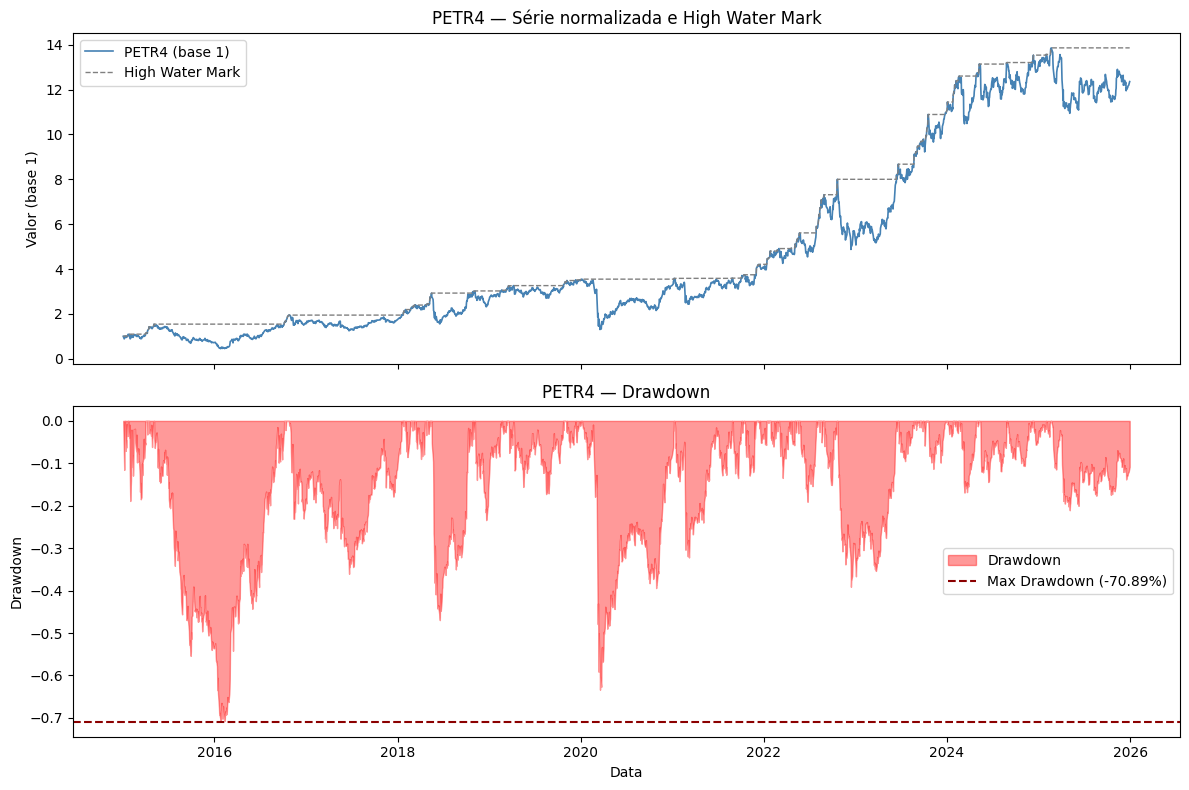

In [8]:
# 5. Visualização
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(serie, color="steelblue", lw=1.2, label="PETR4 (base 1)")
ax1.plot(hwm,   color="gray", lw=1, ls="--", label="High Water Mark")
ax1.set_ylabel("Valor (base 1)")
ax1.legend()
ax1.set_title("PETR4 — Série normalizada e High Water Mark")

ax2.fill_between(drawdown.index, drawdown, 0, color="red", alpha=0.4, label="Drawdown")
ax2.axhline(max_dd, color="darkred", lw=1.5, ls="--", label=f"Max Drawdown ({max_dd:.2%})")
ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Data")
ax2.legend()
ax2.set_title("PETR4 — Drawdown")

plt.tight_layout()
plt.show()

In [ ]:
# 6. Episódios de drawdown
is_dd  = drawdown < 0

'''
Data        drawdown
2020-01-01   0.00    ← no pico
2020-01-02  -0.02    ← em queda
2020-01-03  -0.05    ← em queda
2020-01-04   0.00    ← voltou ao pico
2020-01-05  -0.03    ← em queda
2020-01-06  -0.07    ← em queda
2020-01-07   0.00    ← voltou ao pico

Passo 1: is_dd = drawdown < 0

2020-01-01   False
2020-01-02   True
2020-01-03   True
2020-01-04   False
2020-01-05   True
2020-01-06   True
2020-01-07   False
'''

groups = (~is_dd).cumsum()

'''
2020-01-01   1   ← incrementou (estava no pico)
2020-01-02   1   ← não incrementou (em drawdown)
2020-01-03   1   ← não incrementou
2020-01-04   2   ← incrementou (voltou ao pico)
2020-01-05   2   ← não incrementou
2020-01-06   2   ← não incrementou
2020-01-07   3   ← incrementou
'''

episodes = []
for _, grp in drawdown[is_dd].groupby(groups[is_dd]):
    inicio = grp.index[0]
    vale   = grp.idxmin()
    fim    = grp.index[-1]
    episodes.append({
        "Início"        : inicio.date(),
        "Vale"          : vale.date(),
        "Fim período"   : fim.date(),
        "Max DD"        : grp.min(),
        "Duração (dias)": (fim - inicio).days,
    })

'''Data        drawdown   grupo
2020-01-02  -0.02       1     ← episódio 1
2020-01-03  -0.05       1     ← episódio 1
2020-01-05  -0.03       2     ← episódio 2
2020-01-06  -0.07       2     ← episódio 2
'''

top5 = pd.DataFrame(episodes).sort_values("Max DD").head(5).reset_index(drop=True)
display(top5.round(4))

,Início,Vale,Fim período,Max DD,Duração (dias)
0,2015-05-06,2016-01-26,2016-10-04,-0.7089,517
1,2020-01-07,2020-03-18,2021-01-06,-0.6336,365
2,2018-05-17,2018-06-18,2018-10-25,-0.4696,161
3,2022-10-24,2022-12-14,2023-06-13,-0.3910,232
4,2016-10-25,2017-06-21,2018-01-16,-0.3604,448


In [10]:
# 7. Calmar Ratio
n_anos        = len(serie) / 252
retorno_anual = (serie.iloc[-1] / serie.iloc[0]) ** (1 / n_anos) - 1
calmar        = retorno_anual / abs(max_dd)

print(f"Retorno anualizado : {retorno_anual:.2%}")
print(f"Max Drawdown       : {max_dd:.2%}")
print(f"Calmar Ratio       : {calmar:.2f}")

Retorno anualizado : 26.05%
Max Drawdown       : -70.89%
Calmar Ratio       : 0.37
